In [ ]:
import os
os.environ['PROJ_LIB'] = '/home/users/zhiyi/.conda/envs/plot_musica/share/proj'
import xarray as xr
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import matplotlib
import matplotlib.patheffects as pe
from matplotlib import pyplot as plt
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from zhiyi.plot.Plot_2D import Plot_2D
from glob import glob
from datetime import datetime, timedelta
print('done')

done


In [ ]:
# ne60
se_base_files_nobb= "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICAv0_ne60_production/atm/hist/MUSICAv0_ne60_production.cam.h2.2018-MM-DD-03600.nc"
start_date_nobb = datetime.date(2018, 5, 22)
end_date_nobb = datetime.date(2018, 6, 14)
se_files_nobb = []
current_nobb = start_date_nobb
while current_nobb <= end_date_nobb:
    MM = current_nobb.strftime("%m")
    DD = current_nobb.strftime("%d")
    file_path_nobb = se_base_files_nobb.replace("MM", MM).replace("DD", DD)
    current_nobb += datetime.timedelta(days=1)
ds_uk_nobb = xr.open_mfdataset(se_files_nobb, combine="by_coords")
average_data_ne60BB = ds_uk_nobb.mean(dim="time")

# ne30x16
se_base_files = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/regrid/regridded/regrid_to_ne60_MUSICA_production3.2_BB.cam.h2.2018-MM-DD-03600.nc"
start_date = datetime.date(2018, 5, 22)
end_date = datetime.date(2018, 6, 14)
se_files = []
current = start_date
while current <= end_date:
    MM = current.strftime("%m")
    DD = current.strftime("%d")
    file_path = se_base_files.replace("MM", MM).replace("DD", DD)
    current += datetime.timedelta(days=1)
ds_uk = xr.open_mfdataset(se_files, combine="by_coords")
average_data_BB = ds_uk.mean(dim="time")

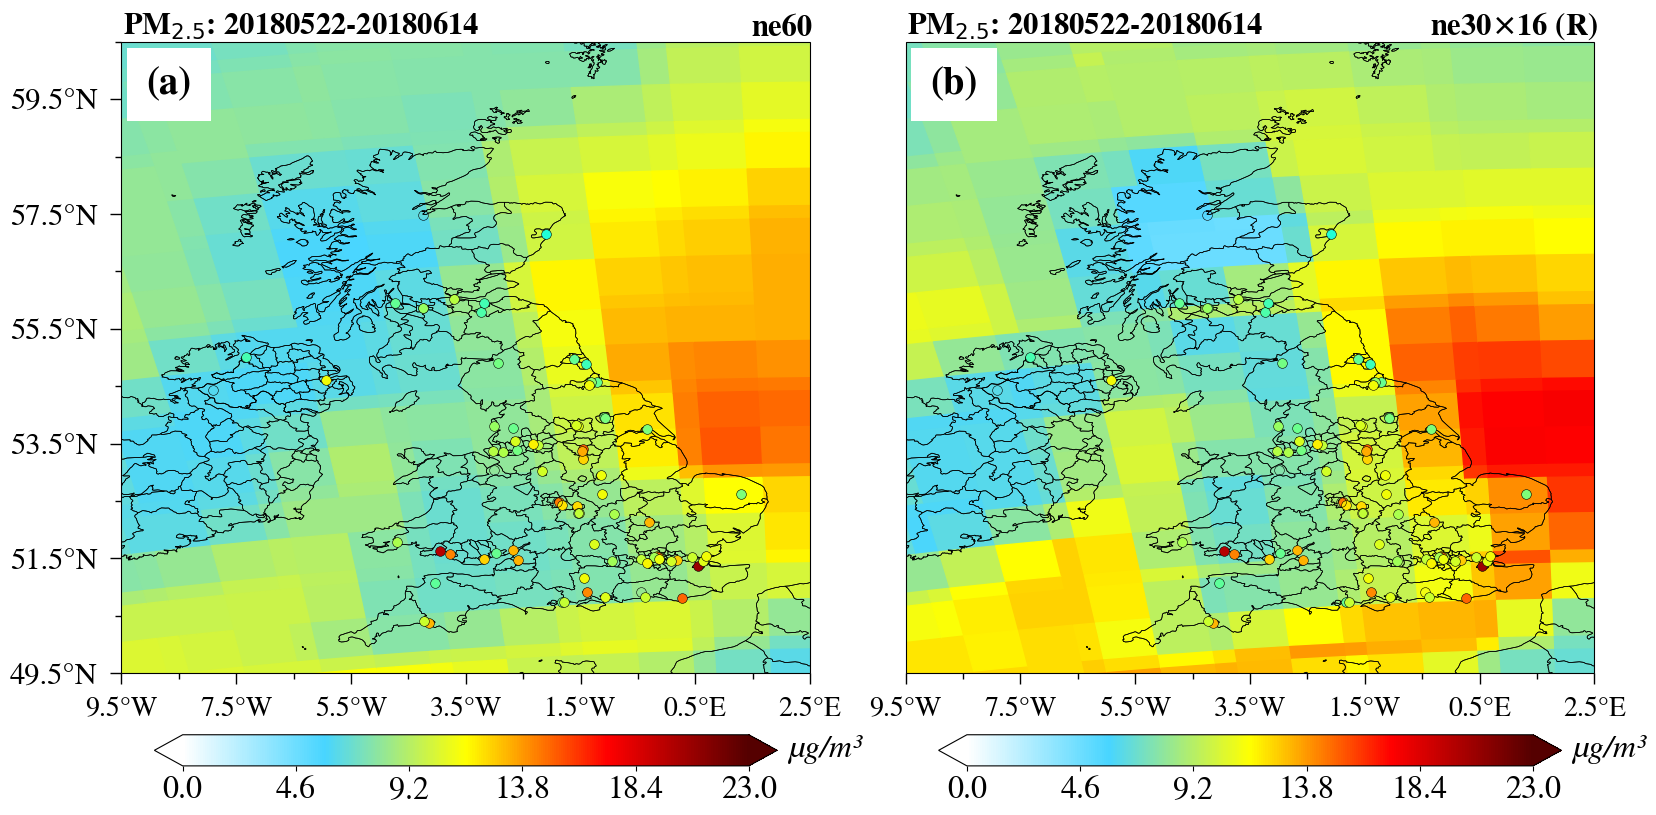

In [ ]:

scrip_filename = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne60/grids/UK_ne60_np4_SCRIP.nc"
scrip_filename_ne60 = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne60/grids/UK_ne60_np4_SCRIP.nc"

pm25_data_ne60BB = average_data_ne60BB['PM25'].isel(lev=-1) * 1e9
pm25_data_BB   = average_data_BB['PM25'].isel(lev=-1) * 1e9

df = pd.read_csv(
    '/home/users/zhiyi/PROJECTS_ANALYSIS/extract_data/project_analysis/aurn_observation/PM25/pm2.5_filtered.csv',
    skiprows=1
)

latobs = df['Latitude'].values
lonobs = df['Longitude'].values + 360
date_cols = [
    c for c in df.columns
    if isinstance(c, str)
    and not pd.isna(pd.to_datetime(c, format='%Y-%m-%d', errors='coerce'))
]

dates = pd.to_datetime(date_cols, format='%Y-%m-%d')
mask = (dates >= pd.to_datetime('2018-05-22')) & (dates <= pd.to_datetime('2018-06-14'))
selected_cols = [date_cols[i] for i, ok in enumerate(mask) if ok]

valobs = df[selected_cols].mean(axis=1).values
color_arr = valobs / 24
color_arr[color_arr > 1] = 1

# PM25
plot_settings = [
    (scrip_filename_ne60, pm25_data_ne60BB, '', 0, 23, 'µg/m³'),
    (scrip_filename, pm25_data_BB, '', 0, 23, 'µg/m³'),
    # (scrip_filename_ne60, pm25_data_regrid, r'', 0, 20, 'µg/m³'),
    # (scrip_filename_ne60, diff, r'', -10, 10, 'µg/m³'),
]

fig, axs = plt.subplots(1, 2, figsize=(25, 10), subplot_kw={'projection': ccrs.PlateCarree()})
for i, (scrip, data, title, vmin, vmax, unit) in enumerate(plot_settings):
    ax = axs.flat[i]
    p = Plot_2D(
        data,
        scrip_file=scrip, pretty_tick=True,
        # lon_range=[-9, 9],
        # lat_range=[49, 61.5],
        lon_range=[-9.5, 2.5],
        lat_range=[49.5, 60.5],
        # lon_range=[-15, 8],
        # lat_range=[45, 62],
        lon_interval=2,
        lat_interval=2,
        resolution="10m",
        country=True, state=True, title=title,
        title_bold=True, unit=unit, 
        nticks=6,
        title_size=20,
        label_size=22,
        cmax=vmax, cmin=vmin, 
        # feature_line_lw=0.45,
        grid_line_lw=0.15,
        # grid_line=True,
        lonlat_line=False,
        shrink=0.54,
        # shrink=0.2,
        # pad=0.093,
        pad=0.08,
        unit_offset=[0.05, 0],
        ax=ax
    )    
    if hasattr(p, 'cb'):
        p.cb.ax.tick_params(labelsize=23)
        for txt in p.cb.ax.texts:
            txt.set_fontsize(23)
            # txt.set_weight('bold')
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))    
    ax.tick_params(axis='x', which='major', labelsize=20, pad=9, length=8, width=1 )
    ax.tick_params(axis='x', which='minor', labelsize=18*0.8, length=4, width=1 )
    
    if i ==0:
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='y', which='major', labelsize=22, pad=9, length=8, width=1, )
        ax.tick_params(axis='y', which='minor', labelsize=18*0.8, length=4, width=1)
    if i ==1:
    # elif i == 1:
        ax.set_ylabel("", fontsize=18, labelpad=25)
        ax.yaxis.set_tick_params(labelleft=False, labelright=False, left=False, right=False)
        # ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        # ax.tick_params(axis='y', which='major', labelsize=20, pad=10, length=8, width=1, labelleft=False, labelright=True, left=False, right=True)
        # ax.tick_params(axis='y', which='minor', labelsize=18*0.8, length=4, width=1, labelleft=False, labelright=True, left=False, right=True)
    # else:
    #     ax.set_ylabel("")
    #     ax.yaxis.set_tick_params(labelleft=False, labelright=False, left=False, right=False)
    if i < 2:
        cmap = plt.colormaps['jet']
        for j in range(np.size(latobs)):
            ax.plot(
            lonobs[j], latobs[j],
            linestyle='none', marker="o", markersize=7,
            c=cmap(color_arr[j]),
            markeredgecolor="black", markeredgewidth=0.4,
            transform=ccrs.PlateCarree()
        )
    ax.set_xlabel("", fontsize=18)
    ax.xaxis.set_tick_params(labelbottom=True)
fig.subplots_adjust(wspace=-0.32, 
                    hspace=0.05,
                    )
for ax in axs.flat:
    ax.set_title(ax.get_title(), fontsize=30, 
                 weight='bold',
                 pad=20)
    
# 01
letters = ['(a)', '(b)']
for i, ax in enumerate(axs.flat):
    ax.text(
            0.036, 0.96,
            # 0.041, 0.96, 
            letters[i], transform=ax.transAxes, 
            fontsize=28, va='top', 
            ha='left', weight='bold',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='square, pad=0.5',  alpha=1))

    title_str = f"PM$_{{2.5}}$: 20180522-20180614"            
    ax.text(
            0.002, 1,                               
            title_str,
            transform=ax.transAxes,
            fontsize=22, va='bottom', ha='left',
            weight='bold', 
            zorder=10)
    if i ==0:
        title_str = r'ne60'           
        ax.text(
            0.915, 1,                               
            title_str,
            transform=ax.transAxes,
            fontsize=22, va='bottom', ha='left',
            weight='bold', 
            zorder=10)
    if i ==1:
        title_str = r'ne30$\times$16 (R)'           
        ax.text(
            0.761, 1,                               
            title_str,
            transform=ax.transAxes,
            fontsize=22, va='bottom', ha='left',
            weight='bold', 
            zorder=10)
        